<a href="https://colab.research.google.com/github/crahulnaidu/quantum_computing/blob/main/month_1/month_1_day_16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qiskit
!pip install qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 74.2 MB/s eta 0:00:00


In [2]:
#period finding in modular exponentiation


In [35]:
from qiskit import QuantumCircuit,transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

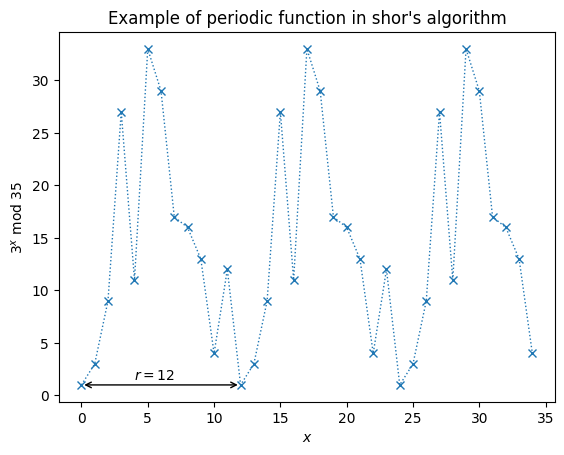

In [20]:
N=35
a=3

xvals=np.arange(35)
yvals=[np.mod(a**x,N)for x in xvals]

fig,ax=plt.subplots()

ax.plot(xvals,yvals,linewidth=1,linestyle='dotted',marker='x')
ax.set(xlabel="$x$",ylabel=f"${a}^x$ mod $ {N}$",title="Example of periodic function in shor's algorithm")


try: # plot r on the graph
    r = yvals[1:].index(1) + 1
    plt.annotate('', xy=(0,1), xytext=(r,1),
                 arrowprops=dict(arrowstyle='<->'))
    plt.annotate(f'$r={r}$', xy=(r/3,1.5))
except ValueError:
    print('Could not find period, check a < N and have no common factors.')


In [25]:
#shor's factoring algorithn for a=7 and N=15

In [27]:
def c_mod15(a,power):
  """controlled multipliation by a mod 15"""
  if a not in[2,4,7,8,11,13]:
    raise ValueError("a must be 2,4,7,8,11,13")
  U=QuantumCircuit(4)
  for _iteration in range(power):
    if a in [2,13]:
      U.swap(2,3)
      U.swap(1,2)
      U.swap(0,1)
    if a in [7,8]:
      U.swap(0,1)
      U.swap(1,2)
      U.swap(2,3)
    if a in [4,11]:
      U.swap(1,3)
      U.swap(0,2)
    if a in [7,11,13]:
      for q in range(4):
        U.x(q)
  U=U.to_gate()
  U.name=f"{a}^{power} mod 15"
  c_u=U.control()
  return c_u


In [28]:
N_COUNT=8
a=7

In [29]:
def qft_dagger(n):
  """n-bit QFT on the first n qubits in the circuit"""
  qc=QuantumCircuit(n)

  for qubit in range(n//2):
    qc.swap(qubit,n-qubit-1)
  for j in range(n):
    for m in range(j):
      qc.cp(-np.pi/float(2**(j-m)),m,j)
    qc.h(j)
  qc.name="QFT†"
  return qc


In [30]:
qc=QuantumCircuit(N_COUNT+4,N_COUNT)

for q in range(N_COUNT):
  qc.h(q)

qc.x(N_COUNT)

for q in range(N_COUNT):
  qc.append(c_mod15(a,2**q),
            [q]+[i+N_COUNT for i in range(4)])

qc.append(qft_dagger(N_COUNT),range(N_COUNT))

qc.measure(range(N_COUNT),range(N_COUNT))
qc.draw(fold=-1)

┌───┐                                                                                                                             ┌───────┐┌─┐                     
 q_0: ┤ H ├───────■─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤0      ├┤M├─────────────────────
      ├───┤       │                                                                                                                     │       │└╥┘┌─┐                  
 q_1: ┤ H ├───────┼──────────────■──────────────────────────────────────────────────────────────────────────────────────────────────────┤1      ├─╫─┤M├──────────────────
      ├───┤       │              │                                                                                                      │       │ ║ └╥┘┌─┐               
 q_2: ┤ H ├───────┼──────────────┼──────────────■───────────────────────────────────────────────────────────────────────────────────────┤2      ├─╫──╫─┤M├───────────────
      ├───┤       │              │              │                                                                                       │       │ ║  ║ └╥┘┌─┐            
 q_3: ┤ H ├───────┼──────────────┼──────────────┼──────────────■────────────────────────────────────────────────────────────────────────┤3      ├─╫──╫──╫─┤M├────────────
      ├───┤       │              │              │              │                                                                        │  QFT† │ ║  ║  ║ └╥┘┌─┐         
 q_4: ┤ H ├───────┼──────────────┼──────────────┼──────────────┼──────────────■─────────────────────────────────────────────────────────┤4      ├─╫──╫──╫──╫─┤M├─────────
      ├───┤       │              │              │              │              │                                                         │       │ ║  ║  ║  ║ └╥┘┌─┐      
 q_5: ┤ H ├───────┼──────────────┼──────────────┼──────────────┼──────────────┼───────────────■─────────────────────────────────────────┤5      ├─╫──╫──╫──╫──╫─┤M├──────
      ├───┤       │              │              │              │              │               │                                         │       │ ║  ║  ║  ║  ║ └╥┘┌─┐   
 q_6: ┤ H ├───────┼──────────────┼──────────────┼──────────────┼──────────────┼───────────────┼───────────────■─────────────────────────┤6      ├─╫──╫──╫──╫──╫──╫─┤M├───
      ├───┤       │              │              │              │              │               │               │                         │       │ ║  ║  ║  ║  ║  ║ └╥┘┌─┐
 q_7: ┤ H ├───────┼──────────────┼──────────────┼──────────────┼──────────────┼───────────────┼───────────────┼────────────────■────────┤7      ├─╫──╫──╫──╫──╫──╫──╫─┤M├
      ├───┤┌──────┴──────┐┌──────┴──────┐┌──────┴──────┐┌──────┴──────┐┌──────┴───────┐┌──────┴───────┐┌──────┴───────┐┌───────┴───────┐└───────┘ ║  ║  ║  ║  ║  ║  ║ └╥┘
 q_8: ┤ X ├┤0            ├┤0            ├┤0            ├┤0            ├┤0             ├┤0             ├┤0             ├┤0              ├──────────╫──╫──╫──╫──╫──╫──╫──╫─
      └───┘│             ││             ││             ││             ││              ││              ││              ││               │          ║  ║  ║  ║  ║  ║  ║  ║ 
 q_9: ─────┤1            ├┤1            ├┤1            ├┤1            ├┤1             ├┤1             ├┤1             ├┤1              ├──────────╫──╫──╫──╫──╫──╫──╫──╫─
           │  7^1 mod 15 ││  7^2 mod 15 ││  7^4 mod 15 ││  7^8 mod 15 ││  7^16 mod 15 ││  7^32 mod 15 ││  7^64 mod 15 ││  7^128 mod 15 │          ║  ║  ║  ║  ║  ║  ║  ║ 
q_10: ─────┤2            ├┤2            ├┤2            ├┤2            ├┤2             ├┤2             ├┤2             ├┤2              ├──────────╫──╫──╫──╫──╫──╫──╫──╫─
           │             ││             ││             ││             ││              ││              ││              ││               │          ║  ║  ║  ║  ║  ║  ║  ║ 
q_11: ─────┤3            ├┤3            ├┤3            ├┤3            ├┤3             ├┤3       

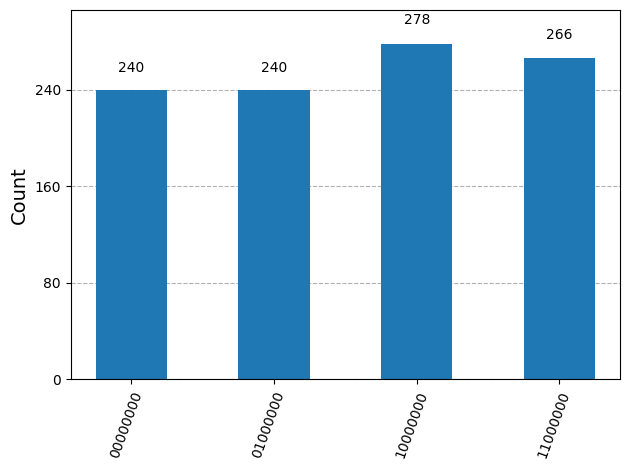

In [34]:
t_qc=transpile(qc,AerSimulator())
counts=AerSimulator().run(t_qc).result().get_counts()

plot_histogram(counts)

In [36]:
rows,measured_phases=[],[]

for output in counts:
  decimal=int(output,2)
  phase=decimal/(2**N_COUNT)
  measured_phases.append(phase)

  rows.append([f"{output}(bin) = {decimal:>3}(dec)",
                 f"{decimal}/{2**N_COUNT} = {phase:.2f}"])

headers=["Registered output","Phase"]

df=pd.DataFrame(rows,columns=headers)
print(df)

          Registered output           Phase
0  11000000(bin) = 192(dec)  192/256 = 0.75
1  01000000(bin) =  64(dec)   64/256 = 0.25
2  00000000(bin) =   0(dec)    0/256 = 0.00
3  10000000(bin) = 128(dec)  128/256 = 0.50
